# Prediksi Kategori Gaji dengan Naive Bayes

1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.naive_bayes import GaussianNB, MultinomialNB, ComplementNB
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

print('✅ Semua library berhasil diimport!')

✅ Semua library berhasil diimport!


2. Load Dataset

In [2]:
df = pd.read_csv('data_karyawan.csv')

print('=' * 55)
print('📊 INFORMASI DASAR DATASET')
print('=' * 55)
print(f'Jumlah data  : {df.shape[0]} karyawan')
print(f'Jumlah fitur : {df.shape[1]} kolom')
print()
df.head(10)

📊 INFORMASI DASAR DATASET
Jumlah data  : 100 karyawan
Jumlah fitur : 5 kolom



,usia,pengalaman_kerja,jenis_kelamin,pendidikan,gaji
0,56,8.0000,Wanita,S2,"5,058,000.0000"
1,46,7.0000,Wanita,SMA,"3,857,000.0000"
2,32,11.0000,Pria,SMA,"5,358,000.0000"
3,25,1.0000,Pria,S2,"5,561,000.0000"
4,38,0.0000,Wanita,SMA,"6,083,000.0000"
5,56,15.0000,Wanita,S2,"6,054,000.0000"
6,36,4.0000,Pria,SMA,"3,622,000.0000"
7,40,2.0000,Pria,D3,"4,062,000.0000"
8,28,11.0000,Wanita,SMA,"5,515,000.0000"
9,28,7.0000,Pria,S2,"5,514,000.0000"


3. Preprocessing & Diskritisasi Gaji

In [3]:
df_proc = df.copy()

# --- Langkah 1: Imputasi missing values pengalaman_kerja ---
median_pengalaman = df_proc['pengalaman_kerja'].median()
df_proc['pengalaman_kerja'] = df_proc['pengalaman_kerja'].fillna(median_pengalaman)
print(f'✅ Missing values pengalaman_kerja diisi median: {median_pengalaman} tahun')

# --- Langkah 2: Diskritisasi gaji menjadi 3 kategori ---
p33 = df_proc['gaji'].quantile(0.33)
p67 = df_proc['gaji'].quantile(0.67)

bins   = [0, p33, p67, float('inf')]
labels = ['Rendah', 'Sedang', 'Tinggi']

df_proc['kategori_gaji'] = pd.cut(df_proc['gaji'], bins=bins, labels=labels)

print(f'\n✅ Diskritisasi gaji:')
print(f'   🔴 Rendah : Gaji < Rp {p33:,.0f}')
print(f'   🟡 Sedang : Rp {p33:,.0f} – Rp {p67:,.0f}')
print(f'   🟢 Tinggi : Gaji > Rp {p67:,.0f}')
print()
print('Distribusi Kategori Gaji:')
print(df_proc['kategori_gaji'].value_counts().sort_index())

✅ Missing values pengalaman_kerja diisi median: 8.0 tahun

✅ Diskritisasi gaji:
   🔴 Rendah : Gaji < Rp 4,515,670
   🟡 Sedang : Rp 4,515,670 – Rp 5,515,000
   🟢 Tinggi : Gaji > Rp 5,515,000

Distribusi Kategori Gaji:
kategori_gaji
Rendah    33
Sedang    35
Tinggi    32
Name: count, dtype: int64


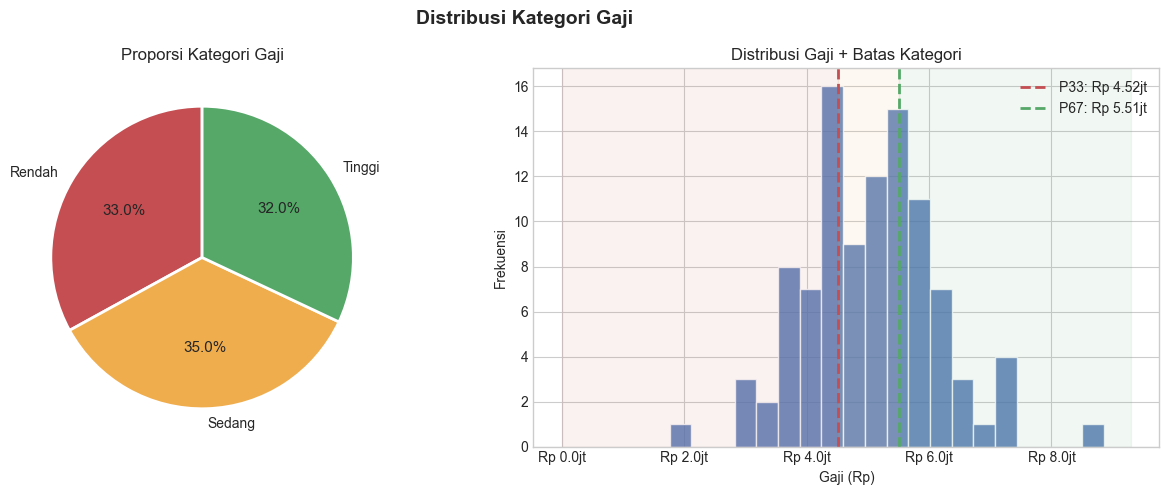

✅ Visualisasi kategori gaji selesai.


In [4]:
# Visualisasi distribusi kategori gaji
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribusi Kategori Gaji', fontsize=14, fontweight='bold')

# Pie chart
cat_counts = df_proc['kategori_gaji'].value_counts().reindex(['Rendah','Sedang','Tinggi'])
colors_cat = ['#C44E52', '#F0AD4E', '#55A868']
wedges, texts, autotexts = axes[0].pie(
    cat_counts.values, labels=cat_counts.index,
    autopct='%1.1f%%', colors=colors_cat,
    startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(11)
axes[0].set_title('Proporsi Kategori Gaji')

# Histogram gaji dengan batas kategori
axes[1].hist(df_proc['gaji'], bins=20, color='#4C72B0', edgecolor='white', alpha=0.8)
axes[1].axvline(p33, color='#C44E52', linestyle='--', lw=2, label=f'P33: Rp {p33/1e6:.2f}jt')
axes[1].axvline(p67, color='#55A868', linestyle='--', lw=2, label=f'P67: Rp {p67/1e6:.2f}jt')
axes[1].set_title('Distribusi Gaji + Batas Kategori')
axes[1].set_xlabel('Gaji (Rp)')
axes[1].set_ylabel('Frekuensi')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x/1e6:.1f}jt'))
axes[1].legend()

# Shading per zona
axes[1].axvspan(0, p33, alpha=0.08, color='#C44E52', label='Rendah')
axes[1].axvspan(p33, p67, alpha=0.08, color='#F0AD4E')
axes[1].axvspan(p67, df_proc['gaji'].max()*1.05, alpha=0.08, color='#55A868')

plt.tight_layout()
plt.savefig('distribusi_kategori_gaji.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualisasi kategori gaji selesai.')

In [5]:
# --- Langkah 3: Encoding fitur ---
df_proc['jenis_kelamin_enc'] = df_proc['jenis_kelamin'].map({'Pria': 1, 'Wanita': 0})
pend_map = {'SMA': 1, 'D3': 2, 'S1': 3, 'S2': 4}
df_proc['pendidikan_enc']    = df_proc['pendidikan'].map(pend_map)

# Encode target label
label_enc = LabelEncoder()
label_enc.fit(['Rendah', 'Sedang', 'Tinggi'])
df_proc['target'] = label_enc.transform(df_proc['kategori_gaji'].astype(str))

print('✅ Encoding selesai:')
print('   Jenis Kelamin : Pria=1, Wanita=0')
print('   Pendidikan    : SMA=1, D3=2, S1=3, S2=4')
print('   Kategori Gaji :', dict(zip(label_enc.classes_, label_enc.transform(label_enc.classes_))))

# Fitur dan target
FEATURES = ['usia', 'pengalaman_kerja', 'jenis_kelamin_enc', 'pendidikan_enc']
X = df_proc[FEATURES].astype(float)
y = df_proc['target']

print(f'\n📊 Shape X: {X.shape} | Shape y: {y.shape}')
print('\nPreview X (5 baris pertama):')
X.head()

✅ Encoding selesai:
   Jenis Kelamin : Pria=1, Wanita=0
   Pendidikan    : SMA=1, D3=2, S1=3, S2=4
   Kategori Gaji : {np.str_('Rendah'): np.int64(0), np.str_('Sedang'): np.int64(1), np.str_('Tinggi'): np.int64(2)}

📊 Shape X: (100, 4) | Shape y: (100,)

Preview X (5 baris pertama):


,usia,pengalaman_kerja,jenis_kelamin_enc,pendidikan_enc
0,56.0000,8.0000,0.0000,4.0000
1,46.0000,7.0000,0.0000,1.0000
2,32.0000,11.0000,1.0000,1.0000
3,25.0000,1.0000,1.0000,4.0000
4,38.0000,0.0000,0.0000,1.0000


3b. Feature Engineering

Menambahkan fitur-fitur baru yang diturunkan dari fitur yang sudah ada untuk memperkaya representasi data dan membantu model menangkap pola yang lebih kompleks.

| Fitur Baru | Deskripsi |
|---|---|
| `rasio_pengalaman_usia` | Proporsi usia yang sudah diisi pengalaman kerja |
| `pengalaman_per_pendidikan` | Rata-rata pengalaman relatif terhadap jenjang pendidikan |
| `skor_produktivitas` | Kombinasi pendidikan × pengalaman sebagai proxy produktivitas |
| `kelompok_usia` | Pengelompokan usia ke dalam 4 rentang (Junior/Mid/Senior/Expert) |
| `usia_x_pendidikan` | Interaksi antara usia dan tingkat pendidikan |
| `pengalaman_kuadrat` | Efek non-linear pengalaman kerja |


In [6]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

# 1. Rasio pengalaman terhadap usia
#    → Mengukur seberapa besar proporsi usia yang sudah diisi kerja
df_proc['rasio_pengalaman_usia'] = df_proc['pengalaman_kerja'] / df_proc['usia']

# 2. Pengalaman relatif terhadap pendidikan
#    → Orang S2 yang baru 1 tahun kerja vs SMA yang sudah 10 tahun bisa berbeda
df_proc['pengalaman_per_pendidikan'] = df_proc['pengalaman_kerja'] / df_proc['pendidikan_enc']

# 3. Skor produktivitas: pendidikan × pengalaman
#    → Proxy: semakin tinggi pendidikan & pengalaman, semakin tinggi produktivitas
df_proc['skor_produktivitas'] = df_proc['pendidikan_enc'] * df_proc['pengalaman_kerja']

# 4. Kelompok usia (binning)
#    → Junior (< 25), Mid (25–35), Senior (35–45), Expert (> 45)
df_proc['kelompok_usia'] = pd.cut(
    df_proc['usia'],
    bins=[0, 25, 35, 45, float('inf')],
    labels=[1, 2, 3, 4]  # ordinal encoding langsung
).astype(float)

# 5. Interaksi usia × pendidikan
#    → Menangkap efek gabungan antara usia dan tingkat pendidikan
df_proc['usia_x_pendidikan'] = df_proc['usia'] * df_proc['pendidikan_enc']

# 6. Pengalaman kuadrat
#    → Menangkap efek non-linear: kenaikan gaji mungkin melambat setelah pengalaman tertentu
df_proc['pengalaman_kuadrat'] = df_proc['pengalaman_kerja'] ** 2

print('✅ Feature Engineering selesai! Fitur baru yang ditambahkan:')
new_features = [
    'rasio_pengalaman_usia', 'pengalaman_per_pendidikan',
    'skor_produktivitas', 'kelompok_usia',
    'usia_x_pendidikan', 'pengalaman_kuadrat'
]
for f in new_features:
    print(f'   ✔ {f}')

print(f'\nTotal fitur sebelum FE : 4')
print(f'Total fitur setelah FE : {4 + len(new_features)}')

# Update daftar FEATURES dengan fitur baru
FEATURES = [
    'usia', 'pengalaman_kerja', 'jenis_kelamin_enc', 'pendidikan_enc',
    'rasio_pengalaman_usia', 'pengalaman_per_pendidikan',
    'skor_produktivitas', 'kelompok_usia',
    'usia_x_pendidikan', 'pengalaman_kuadrat'
]

X = df_proc[FEATURES].astype(float)
y = df_proc['target']

print(f'\n📊 Shape X (setelah FE): {X.shape} | Shape y: {y.shape}')
print('\nPreview X dengan fitur baru (5 baris pertama):')
X.head()


✅ Feature Engineering selesai! Fitur baru yang ditambahkan:
   ✔ rasio_pengalaman_usia
   ✔ pengalaman_per_pendidikan
   ✔ skor_produktivitas
   ✔ kelompok_usia
   ✔ usia_x_pendidikan
   ✔ pengalaman_kuadrat

Total fitur sebelum FE : 4
Total fitur setelah FE : 10

📊 Shape X (setelah FE): (100, 10) | Shape y: (100,)

Preview X dengan fitur baru (5 baris pertama):


,usia,pengalaman_kerja,jenis_kelamin_enc,pendidikan_enc,rasio_pengalaman_usia,pengalaman_per_pendidikan,skor_produktivitas,kelompok_usia,usia_x_pendidikan,pengalaman_kuadrat
0,56.0000,8.0000,0.0000,4.0000,0.1429,2.0000,32.0000,4.0000,224.0000,64.0000
1,46.0000,7.0000,0.0000,1.0000,0.1522,7.0000,7.0000,4.0000,46.0000,49.0000
2,32.0000,11.0000,1.0000,1.0000,0.3438,11.0000,11.0000,2.0000,32.0000,121.0000
3,25.0000,1.0000,1.0000,4.0000,0.0400,0.2500,4.0000,1.0000,100.0000,1.0000
4,38.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,3.0000,38.0000,0.0000


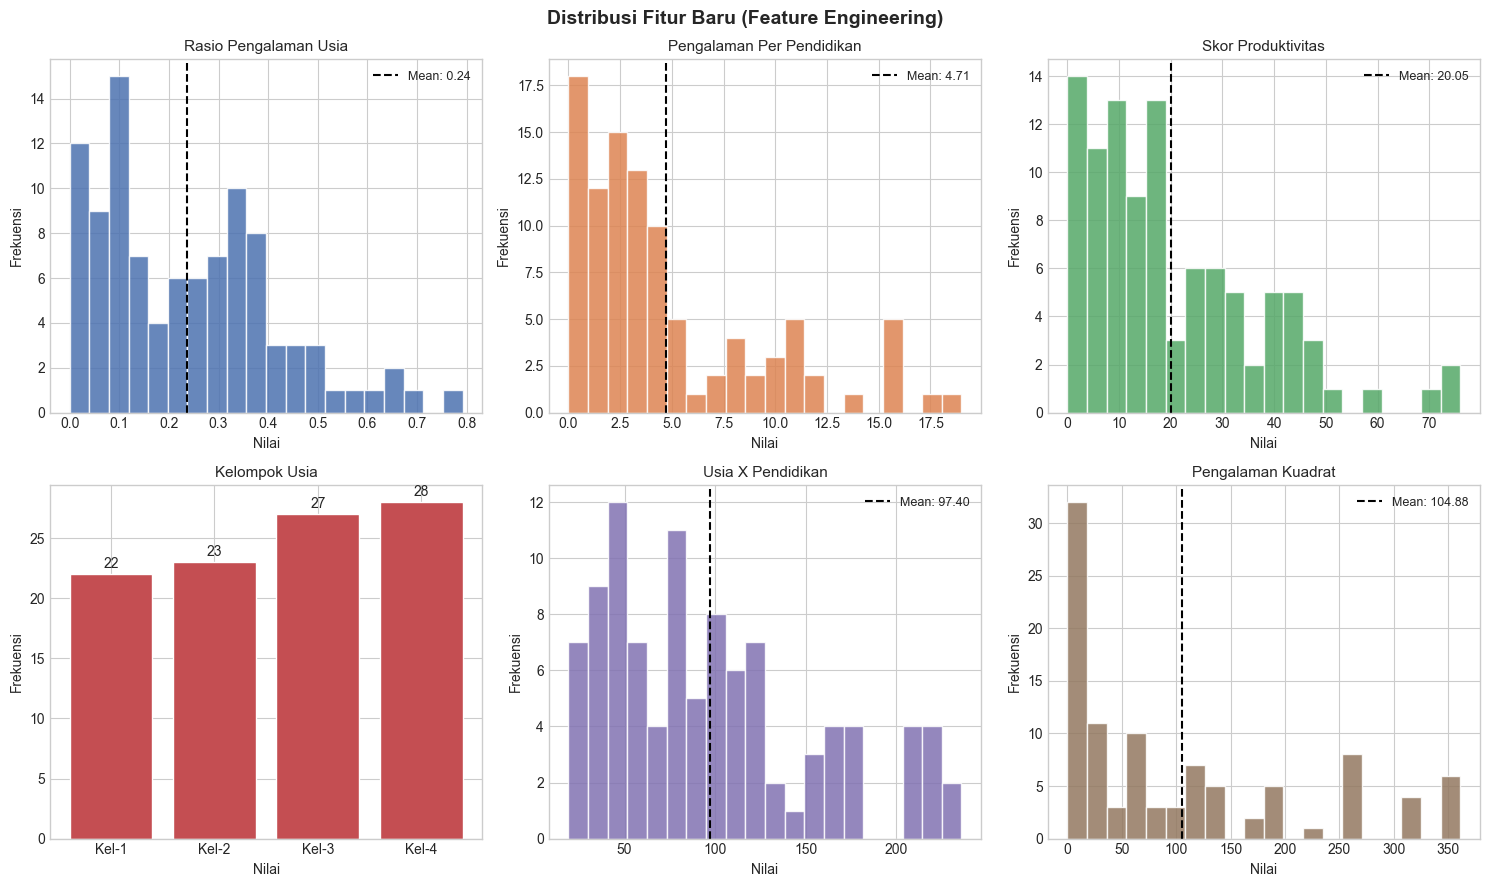

✅ Visualisasi distribusi fitur baru selesai.


In [7]:
# Visualisasi distribusi fitur-fitur baru
new_features = [
    'rasio_pengalaman_usia', 'pengalaman_per_pendidikan',
    'skor_produktivitas', 'kelompok_usia',
    'usia_x_pendidikan', 'pengalaman_kuadrat'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Distribusi Fitur Baru (Feature Engineering)', fontsize=14, fontweight='bold')
axes = axes.flatten()

palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']

for i, (feat, color) in enumerate(zip(new_features, palette)):
    ax = axes[i]
    data_feat = df_proc[feat].dropna()

    if feat == 'kelompok_usia':
        # Bar chart untuk fitur ordinal
        counts = data_feat.value_counts().sort_index()
        ax.bar([f'Kel-{int(k)}' for k in counts.index], counts.values, color=color, edgecolor='white')
        for j, v in enumerate(counts.values):
            ax.text(j, v + 0.5, str(v), ha='center', fontsize=10)
    else:
        ax.hist(data_feat, bins=20, color=color, edgecolor='white', alpha=0.85)
        ax.axvline(data_feat.mean(), color='black', linestyle='--', lw=1.5,
                   label=f'Mean: {data_feat.mean():.2f}')
        ax.legend(fontsize=9)

    ax.set_title(feat.replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig('distribusi_fitur_baru.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualisasi distribusi fitur baru selesai.')


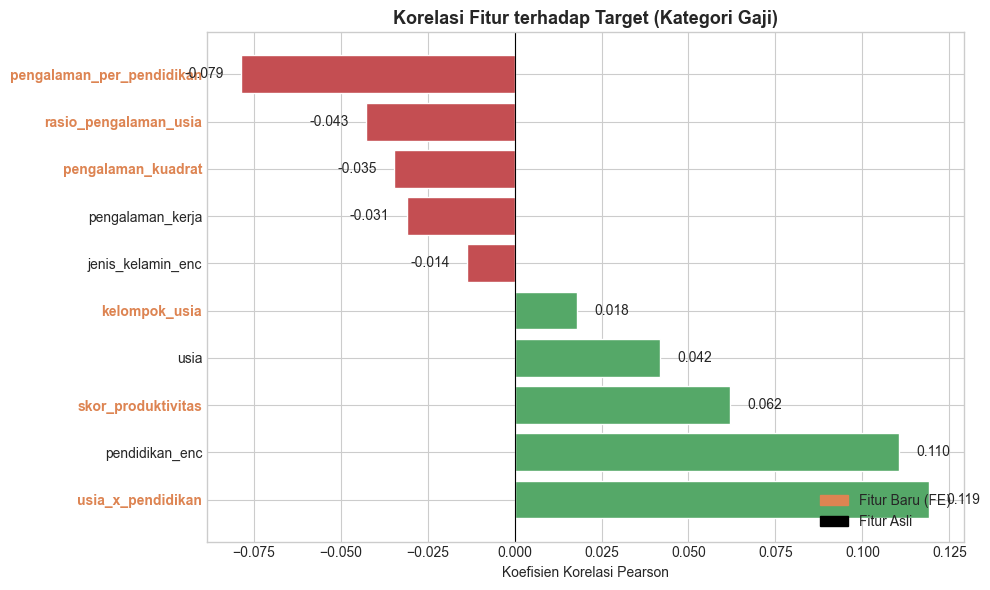

✅ Visualisasi korelasi fitur selesai.

📊 Korelasi fitur terhadap target (dari tertinggi ke terendah):
   usia_x_pendidikan              : +0.1192 ⬅ (FE)
   pendidikan_enc                 : +0.1105
   skor_produktivitas             : +0.0618 ⬅ (FE)
   usia                           : +0.0417
   kelompok_usia                  : +0.0179 ⬅ (FE)
   jenis_kelamin_enc              : -0.0137
   pengalaman_kerja               : -0.0310
   pengalaman_kuadrat             : -0.0347 ⬅ (FE)
   rasio_pengalaman_usia          : -0.0427 ⬅ (FE)
   pengalaman_per_pendidikan      : -0.0785 ⬅ (FE)


In [8]:
# Korelasi fitur baru terhadap target (kategori gaji)
all_features = [
    'usia', 'pengalaman_kerja', 'jenis_kelamin_enc', 'pendidikan_enc',
    'rasio_pengalaman_usia', 'pengalaman_per_pendidikan',
    'skor_produktivitas', 'kelompok_usia',
    'usia_x_pendidikan', 'pengalaman_kuadrat'
]

corr_vals = df_proc[all_features].corrwith(df_proc['target']).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#55A868' if v >= 0 else '#C44E52' for v in corr_vals.values]
bars = ax.barh(corr_vals.index, corr_vals.values, color=colors, edgecolor='white')

for bar, val in zip(bars, corr_vals.values):
    xpos = val + 0.005 if val >= 0 else val - 0.005
    ha = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
            va='center', ha=ha, fontsize=10)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Korelasi Fitur terhadap Target (Kategori Gaji)', fontsize=13, fontweight='bold')
ax.set_xlabel('Koefisien Korelasi Pearson')

# Tandai fitur baru
new_feat_set = {
    'rasio_pengalaman_usia', 'pengalaman_per_pendidikan',
    'skor_produktivitas', 'kelompok_usia',
    'usia_x_pendidikan', 'pengalaman_kuadrat'
}
for label in ax.get_yticklabels():
    if label.get_text() in new_feat_set:
        label.set_color('#DD8452')
        label.set_fontweight('bold')

legend_handles = [
    mpatches.Patch(color='#DD8452', label='Fitur Baru (FE)'),
    mpatches.Patch(color='black',   label='Fitur Asli')
]
ax.legend(handles=legend_handles, loc='lower right')

plt.tight_layout()
plt.savefig('korelasi_fitur_baru.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualisasi korelasi fitur selesai.')
print()
print('📊 Korelasi fitur terhadap target (dari tertinggi ke terendah):')
for feat, val in corr_vals.items():
    tag = ' ⬅ (FE)' if feat in new_feat_set else ''
    print(f'   {feat:<30} : {val:+.4f}{tag}')


4. Split Data – Train & Test

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('✅ Data berhasil dibagi (stratified split):')
print(f'   Training set : {X_train.shape[0]} data (80%)')
print(f'   Test set     : {X_test.shape[0]} data (20%)')
print()
print('Distribusi kelas pada training set:')
for enc, nm in zip(label_enc.transform(label_enc.classes_), label_enc.classes_):
    print(f'   {nm}: {(y_train == enc).sum()} data')

✅ Data berhasil dibagi (stratified split):
   Training set : 80 data (80%)
   Test set     : 20 data (20%)

Distribusi kelas pada training set:
   Rendah: 26 data
   Sedang: 28 data
   Tinggi: 26 data


5. Pembuatan Model Naive Bayes

Terdapat **3 varian Naive Bayes** yang diuji:

| Varian | Asumsi Distribusi | Cocok untuk |
|--------|------------------|-------------|
| **Gaussian NB** | Fitur berdistribusi normal | Fitur kontinu (usia, pengalaman) |
| **Multinomial NB** | Fitur berupa frekuensi/count | Data teks / frekuensi |
| **Complement NB** | Seperti Multinomial, tapi lebih robust | Dataset tidak seimbang |

In [10]:
# Untuk Multinomial & Complement NB, fitur harus non-negatif → MinMaxScaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Definisi model
nb_models = {
    'Gaussian NB'    : (GaussianNB(),    X_train,        X_test),
    'Multinomial NB' : (MultinomialNB(), X_train_scaled, X_test_scaled),
    'Complement NB'  : (ComplementNB(),  X_train_scaled, X_test_scaled),
}

nb_results = {}

for name, (model, X_tr, X_te) in nb_models.items():
    model.fit(X_tr, y_train)
    y_pred   = model.predict(X_te)
    y_prob   = model.predict_proba(X_te)
    acc      = accuracy_score(y_test, y_pred)
    
    # Cross-validation (5-fold stratified)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_acc = cross_val_score(model, X_tr, y_train, cv=skf, scoring='accuracy')
    
    nb_results[name] = {
        'model'   : model,
        'y_pred'  : y_pred,
        'y_prob'  : y_prob,
        'acc'     : acc,
        'cv_mean' : cv_acc.mean(),
        'cv_std'  : cv_acc.std(),
        'X_test'  : X_te
    }
    print(f'✅ {name:<18} | Accuracy: {acc:.4f} | CV Accuracy: {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')

print('\n🎯 Semua model Naive Bayes selesai dilatih!')

✅ Gaussian NB        | Accuracy: 0.1500 | CV Accuracy: 0.3750 ± 0.0559
✅ Multinomial NB     | Accuracy: 0.2000 | CV Accuracy: 0.2625 ± 0.0468
✅ Complement NB      | Accuracy: 0.2000 | CV Accuracy: 0.2125 ± 0.0500

🎯 Semua model Naive Bayes selesai dilatih!


6. Evaluasi dan Perbandingan Model

In [11]:
# Tabel ringkasan
rows = []
for name, res in nb_results.items():
    rows.append({
        'Model'         : name,
        'Accuracy (%)' : f"{res['acc']*100:.2f}%",
        'CV Acc Mean'  : f"{res['cv_mean']*100:.2f}%",
        'CV Acc Std'   : f"±{res['cv_std']*100:.2f}%",
    })

df_summary = pd.DataFrame(rows)
print('=' * 65)
print('📊 RINGKASAN PERBANDINGAN VARIAN NAIVE BAYES')
print('=' * 65)
print(df_summary.to_string(index=False))
print()

best_nb_name = max(nb_results, key=lambda k: nb_results[k]['acc'])
print(f'🏆 Model terbaik: {best_nb_name} (Accuracy: {nb_results[best_nb_name]["acc"]*100:.2f}%)')

📊 RINGKASAN PERBANDINGAN VARIAN NAIVE BAYES
         Model Accuracy (%) CV Acc Mean CV Acc Std
   Gaussian NB       15.00%      37.50%     ±5.59%
Multinomial NB       20.00%      26.25%     ±4.68%
 Complement NB       20.00%      21.25%     ±5.00%

🏆 Model terbaik: Multinomial NB (Accuracy: 20.00%)


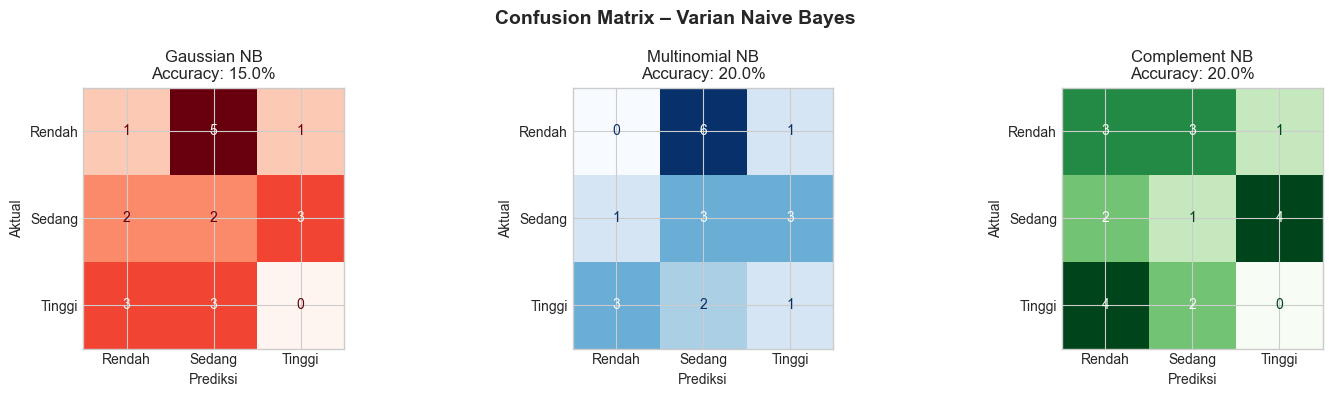

✅ Confusion matrix selesai.


In [12]:
# Confusion Matrix untuk semua varian
class_names = label_enc.classes_  # ['Rendah', 'Sedang', 'Tinggi']
colors_cm = ['Reds', 'Blues', 'Greens']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrix – Varian Naive Bayes', fontsize=14, fontweight='bold')

for ax, (name, res), cmap in zip(axes, nb_results.items(), colors_cm):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(f'{name}\nAccuracy: {res["acc"]*100:.1f}%')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.tight_layout()
plt.savefig('confusion_matrix_nb.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrix selesai.')

In [13]:
# Classification Report model terbaik
best_res = nb_results[best_nb_name]
print(f'=' * 60)
print(f'📋 CLASSIFICATION REPORT – {best_nb_name}')
print(f'=' * 60)
print(classification_report(
    y_test, best_res['y_pred'],
    target_names=class_names
))
print('Keterangan:')
print('  Precision = dari semua yg diprediksi kelas X, berapa % yang benar')
print('  Recall    = dari semua yg sebenarnya kelas X, berapa % yang terdeteksi')
print('  F1-Score  = rata-rata harmonis Precision dan Recall')

📋 CLASSIFICATION REPORT – Multinomial NB
              precision    recall  f1-score   support

      Rendah       0.00      0.00      0.00         7
      Sedang       0.27      0.43      0.33         7
      Tinggi       0.20      0.17      0.18         6

    accuracy                           0.20        20
   macro avg       0.16      0.20      0.17        20
weighted avg       0.16      0.20      0.17        20

Keterangan:
  Precision = dari semua yg diprediksi kelas X, berapa % yang benar
  Recall    = dari semua yg sebenarnya kelas X, berapa % yang terdeteksi
  F1-Score  = rata-rata harmonis Precision dan Recall


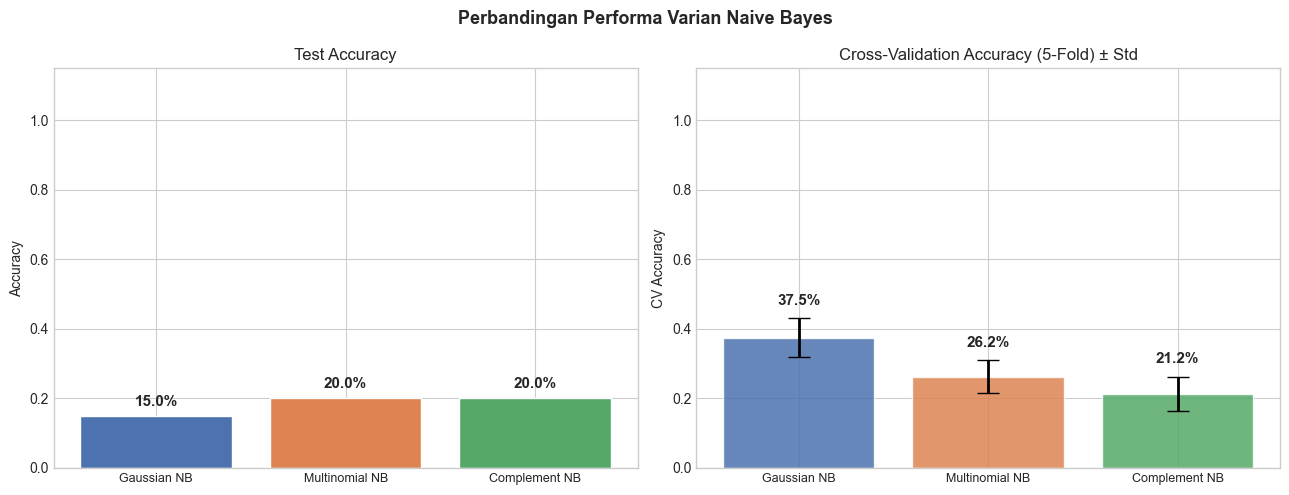

✅ Visualisasi perbandingan selesai.


In [14]:
# Bar chart perbandingan accuracy
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Perbandingan Performa Varian Naive Bayes', fontsize=13, fontweight='bold')

model_labels = list(nb_results.keys())
acc_vals  = [r['acc'] for r in nb_results.values()]
cv_vals   = [r['cv_mean'] for r in nb_results.values()]
cv_stds   = [r['cv_std'] for r in nb_results.values()]
bar_colors = ['#4C72B0', '#DD8452', '#55A868']

# Test Accuracy
bars = axes[0].bar(model_labels, acc_vals, color=bar_colors, edgecolor='white')
axes[0].set_title('Test Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.15)
for bar, val in zip(bars, acc_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val*100:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', labelsize=9)

# CV Accuracy dengan error bar
axes[1].bar(model_labels, cv_vals, color=bar_colors, edgecolor='white', alpha=0.85)
axes[1].errorbar(model_labels, cv_vals, yerr=cv_stds, fmt='none',
                 color='black', capsize=8, linewidth=2)
axes[1].set_title('Cross-Validation Accuracy (5-Fold) ± Std')
axes[1].set_ylabel('CV Accuracy')
axes[1].set_ylim(0, 1.15)
for i, (val, std) in enumerate(zip(cv_vals, cv_stds)):
    axes[1].text(i, val + std + 0.03,
                 f'{val*100:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.savefig('perbandingan_nb.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualisasi perbandingan selesai.')

7. Analisis Probabilitas Prediksi (Gaussian NB)

In [15]:
# Tampilkan probabilitas prediksi pada data test (Gaussian NB)
gnb_res   = nb_results['Gaussian NB']
df_prob   = pd.DataFrame(
    gnb_res['y_prob'],
    columns=[f'P({c})' for c in class_names]
)
df_prob['Prediksi']    = label_enc.inverse_transform(gnb_res['y_pred'])
df_prob['Aktual']      = label_enc.inverse_transform(y_test.values)
df_prob['Benar?']      = df_prob['Prediksi'] == df_prob['Aktual']
df_prob['Benar?']      = df_prob['Benar?'].map({True: '✅', False: '❌'})

print('📊 Probabilitas Prediksi – Gaussian Naive Bayes (10 data pertama):')
print(df_prob.head(10).to_string(index=False))

📊 Probabilitas Prediksi – Gaussian Naive Bayes (10 data pertama):
 P(Rendah)  P(Sedang)  P(Tinggi) Prediksi Aktual Benar?
    0.1451     0.6201     0.2348   Sedang Rendah      ❌
    0.0539     0.7982     0.1479   Sedang Tinggi      ❌
    0.2892     0.2028     0.5079   Tinggi Rendah      ❌
    0.0509     0.7259     0.2231   Sedang Rendah      ❌
    0.4546     0.0597     0.4857   Tinggi Sedang      ❌
    0.2640     0.4786     0.2574   Sedang Tinggi      ❌
    0.2611     0.4752     0.2637   Sedang Rendah      ❌
    0.1617     0.2017     0.6366   Tinggi Sedang      ❌
    0.6580     0.0266     0.3154   Rendah Tinggi      ❌
    0.3040     0.3975     0.2985   Sedang Rendah      ❌


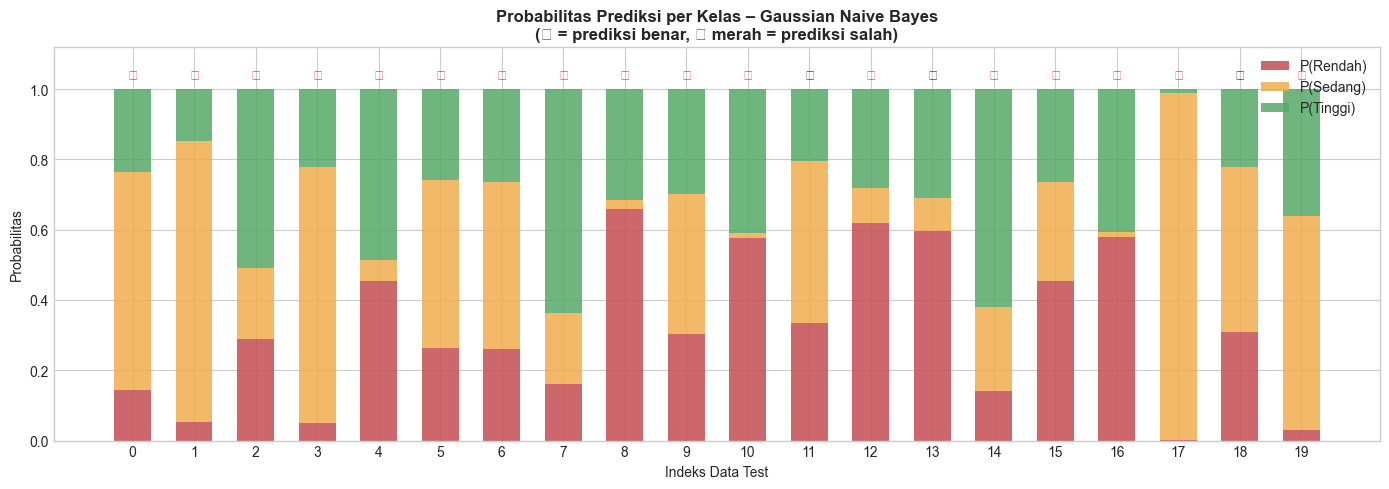

✅ Visualisasi probabilitas prediksi selesai.


In [16]:
# Visualisasi probabilitas prediksi (stacked bar) untuk 20 sampel test
n_show = 20
prob_subset = gnb_res['y_prob'][:n_show]
actual_labels = label_enc.inverse_transform(y_test.values[:n_show])
pred_labels   = label_enc.inverse_transform(gnb_res['y_pred'][:n_show])

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(n_show)
width = 0.6

p1 = ax.bar(x, prob_subset[:, 0], width, label='P(Rendah)', color='#C44E52', alpha=0.85)
p2 = ax.bar(x, prob_subset[:, 1], width, bottom=prob_subset[:, 0],
            label='P(Sedang)', color='#F0AD4E', alpha=0.85)
p3 = ax.bar(x, prob_subset[:, 2], width,
            bottom=prob_subset[:, 0] + prob_subset[:, 1],
            label='P(Tinggi)', color='#55A868', alpha=0.85)

# Tandai prediksi salah
for i, (act, pred) in enumerate(zip(actual_labels, pred_labels)):
    color = 'black' if act == pred else 'red'
    marker = '★' if act == pred else '✗'
    ax.text(i, 1.02, marker, ha='center', va='bottom', fontsize=10, color=color)

ax.set_xlabel('Indeks Data Test')
ax.set_ylabel('Probabilitas')
ax.set_title(
    'Probabilitas Prediksi per Kelas – Gaussian Naive Bayes\n'
    '(★ = prediksi benar, ✗ merah = prediksi salah)',
    fontsize=12, fontweight='bold'
)
ax.set_xticks(x)
ax.set_ylim(0, 1.12)
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('probabilitas_prediksi.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualisasi probabilitas prediksi selesai.')

8. Prediksi Kategori Gaji Calon Karyawan Baru

In [17]:
# Pilih model terbaik berdasarkan accuracy
best_model_obj = nb_results[best_nb_name]['model']
use_scaled     = best_nb_name != 'Gaussian NB'

def prediksi_kategori_gaji(usia, pengalaman_kerja, jenis_kelamin, pendidikan):
    """
    Memprediksi kategori gaji calon karyawan menggunakan model Naive Bayes terbaik.
    
    Parameters:
    - usia            : int   – usia karyawan (tahun)
    - pengalaman_kerja: float – pengalaman kerja (tahun)
    - jenis_kelamin   : str   – 'Pria' atau 'Wanita'
    - pendidikan      : str   – 'SMA', 'D3', 'S1', atau 'S2'
    
    Returns:
    - str  : kategori gaji ('Rendah', 'Sedang', 'Tinggi')
    - dict : probabilitas per kategori
    """
    jk_enc   = 1 if jenis_kelamin == 'Pria' else 0
    pend_enc = {'SMA': 1, 'D3': 2, 'S1': 3, 'S2': 4}[pendidikan]

    # --- Fitur asli ---
    # Fitur-fitur baru (Feature Engineering) — harus konsisten dengan training
    rasio_pengalaman_usia    = pengalaman_kerja / usia
    pengalaman_per_pendidikan = pengalaman_kerja / pend_enc
    skor_produktivitas        = pend_enc * pengalaman_kerja
    if usia <= 25:
        kelompok_usia = 1.0
    elif usia <= 35:
        kelompok_usia = 2.0
    elif usia <= 45:
        kelompok_usia = 3.0
    else:
        kelompok_usia = 4.0
    usia_x_pendidikan  = usia * pend_enc
    pengalaman_kuadrat = pengalaman_kerja ** 2

    X_input = np.array([[
        usia, pengalaman_kerja, jk_enc, pend_enc,
        rasio_pengalaman_usia, pengalaman_per_pendidikan,
        skor_produktivitas, kelompok_usia,
        usia_x_pendidikan, pengalaman_kuadrat
    ]], dtype=float)

    if use_scaled:
        X_input = scaler.transform(X_input)

    pred_enc  = best_model_obj.predict(X_input)[0]
    prob      = best_model_obj.predict_proba(X_input)[0]
    kategori  = label_enc.inverse_transform([pred_enc])[0]
    prob_dict = {c: p for c, p in zip(label_enc.classes_, prob)}

    return kategori, prob_dict

print(f'✅ Fungsi prediksi siap menggunakan model: {best_nb_name}')


✅ Fungsi prediksi siap menggunakan model: Multinomial NB


In [18]:
EMOJI = {'Rendah': '🔴', 'Sedang': '🟡', 'Tinggi': '🟢'}

calon = [
    {'Nama': 'Budi Santoso',  'Usia': 28, 'Pengalaman': 3,  'JK': 'Pria',   'Pend': 'S1'},
    {'Nama': 'Sari Dewi',     'Usia': 35, 'Pengalaman': 10, 'JK': 'Wanita', 'Pend': 'S2'},
    {'Nama': 'Andi Pratama',  'Usia': 22, 'Pengalaman': 1,  'JK': 'Pria',   'Pend': 'D3'},
    {'Nama': 'Rina Wijaya',   'Usia': 45, 'Pengalaman': 18, 'JK': 'Wanita', 'Pend': 'S2'},
    {'Nama': 'Doni Saputra',  'Usia': 30, 'Pengalaman': 5,  'JK': 'Pria',   'Pend': 'SMA'},
    {'Nama': 'Lina Hartati',  'Usia': 40, 'Pengalaman': 12, 'JK': 'Wanita', 'Pend': 'S1'},
]

print('=' * 90)
print(f'🔮 PREDIKSI KATEGORI GAJI CALON KARYAWAN BARU  (Model: {best_nb_name})')
print('=' * 90)
print(f'{"Nama":<16} {"Usia":>5} {"Pengalaman":>12} {"JK":<8} {"Pend":>5}  {"Kategori":<10}  {"P(Rendah)":>10} {"P(Sedang)":>10} {"P(Tinggi)":>10}')
print('-' * 90)

for c in calon:
    kat, prob = prediksi_kategori_gaji(c['Usia'], c['Pengalaman'], c['JK'], c['Pend'])
    emoji = EMOJI[kat]
    print(
        f"{c['Nama']:<16} {c['Usia']:>5} {c['Pengalaman']:>9} thn  "
        f"{c['JK']:<8} {c['Pend']:>5}  "
        f"{emoji} {kat:<8}  "
        f"{prob['Rendah']:>10.1%} {prob['Sedang']:>10.1%} {prob['Tinggi']:>10.1%}"
    )

print('=' * 90)
print()
print(f'🔴 Rendah : Gaji < Rp {p33:,.0f}')
print(f'🟡 Sedang : Rp {p33:,.0f} – Rp {p67:,.0f}')
print(f'🟢 Tinggi : Gaji > Rp {p67:,.0f}')

🔮 PREDIKSI KATEGORI GAJI CALON KARYAWAN BARU  (Model: Multinomial NB)
Nama              Usia   Pengalaman JK        Pend  Kategori     P(Rendah)  P(Sedang)  P(Tinggi)
------------------------------------------------------------------------------------------
Budi Santoso        28         3 thn  Pria        S1  🔴 Rendah         36.2%      30.8%      33.0%
Sari Dewi           35        10 thn  Wanita      S2  🟡 Sedang         29.5%      35.4%      35.1%
Andi Pratama        22         1 thn  Pria        D3  🔴 Rendah         36.0%      31.3%      32.7%
Rina Wijaya         45        18 thn  Wanita      S2  🟡 Sedang         25.8%      40.0%      34.2%
Doni Saputra        30         5 thn  Pria       SMA  🔴 Rendah         35.5%      33.3%      31.2%
Lina Hartati        40        12 thn  Wanita      S1  🟡 Sedang         29.6%      37.1%      33.3%

🔴 Rendah : Gaji < Rp 4,515,670
🟡 Sedang : Rp 4,515,670 – Rp 5,515,000
🟢 Tinggi : Gaji > Rp 5,515,000


9. Kesimpulan

In [19]:
print('=' * 70)
print('📝 KESIMPULAN')
print('=' * 70)
print()
print('1. PENDEKATAN NAIVE BAYES UNTUK PREDIKSI GAJI')
print('   Karena Naive Bayes adalah algoritma klasifikasi, gaji kontinu')
print('   didiskritisasi menjadi 3 kategori (Rendah / Sedang / Tinggi)')
print('   menggunakan batas persentil ke-33 dan ke-67.')
print()
print('2. HASIL PERBANDINGAN VARIAN NAIVE BAYES:')
for name, res in nb_results.items():
    mark = '🏆' if name == best_nb_name else '  '
    print(f'   {mark} {name:<18} | Acc: {res["acc"]*100:.1f}% | CV: {res["cv_mean"]*100:.1f}% ± {res["cv_std"]*100:.1f}%')
print()
print(f'3. MODEL TERBAIK: {best_nb_name}')
print(f'   Accuracy  : {nb_results[best_nb_name]["acc"]*100:.1f}%')
print(f'   CV Acc    : {nb_results[best_nb_name]["cv_mean"]*100:.1f}% ± {nb_results[best_nb_name]["cv_std"]*100:.1f}%')
print()
print('4. KEUNGGULAN NAIVE BAYES:')
print('   ✅ Menghasilkan probabilitas per kategori (tidak hanya label)')
print('   ✅ Cepat dilatih, cocok untuk dataset kecil')
print('   ✅ Mudah diinterpretasikan oleh non-teknis')
print()
print('5. KETERBATASAN NAIVE BAYES:')
print('   ⚠️  Asumsi independensi fitur (jarang terpenuhi sepenuhnya)')
print('   ⚠️  Prediksi berbentuk kategori, bukan angka gaji eksak')
print('   ⚠️  Untuk prediksi gaji presisi, model regresi lebih disarankan')
print()
print('6. REKOMENDASI UNTUK MIRNA:')
print('   ✅ Gunakan Naive Bayes untuk screening awal & penentuan range gaji')
print('   ✅ Kombinasikan dengan model regresi (Random Forest) untuk angka pasti')
print('   ✅ Manfaatkan output probabilitas untuk negosiasi yang lebih fleksibel')
print('=' * 70)

📝 KESIMPULAN

1. PENDEKATAN NAIVE BAYES UNTUK PREDIKSI GAJI
   Karena Naive Bayes adalah algoritma klasifikasi, gaji kontinu
   didiskritisasi menjadi 3 kategori (Rendah / Sedang / Tinggi)
   menggunakan batas persentil ke-33 dan ke-67.

2. HASIL PERBANDINGAN VARIAN NAIVE BAYES:
      Gaussian NB        | Acc: 15.0% | CV: 37.5% ± 5.6%
   🏆 Multinomial NB     | Acc: 20.0% | CV: 26.2% ± 4.7%
      Complement NB      | Acc: 20.0% | CV: 21.2% ± 5.0%

3. MODEL TERBAIK: Multinomial NB
   Accuracy  : 20.0%
   CV Acc    : 26.2% ± 4.7%

4. KEUNGGULAN NAIVE BAYES:
   ✅ Menghasilkan probabilitas per kategori (tidak hanya label)
   ✅ Cepat dilatih, cocok untuk dataset kecil
   ✅ Mudah diinterpretasikan oleh non-teknis

5. KETERBATASAN NAIVE BAYES:
   ⚠️  Asumsi independensi fitur (jarang terpenuhi sepenuhnya)
   ⚠️  Prediksi berbentuk kategori, bukan angka gaji eksak
   ⚠️  Untuk prediksi gaji presisi, model regresi lebih disarankan

6. REKOMENDASI UNTUK MIRNA:
   ✅ Gunakan Naive Bayes untuk scree

2 – Peran *Feature Engineering* dalam Machine Learning

Pengertian Feature Engineering

Feature engineering adalah proses menciptakan, mengubah, atau memilih fitur (variabel input) dari data mentah agar model Machine Learning dapat belajar lebih efektif. Tujuan utamanya adalah membantu model menangkap pola yang lebih kompleks yang tidak bisa ditangkap hanya dari fitur asli saja.

---

### Peran Feature Engineering

**1. Meningkatkan Representasi Data**  
Fitur asli seringkali tidak cukup menggambarkan hubungan yang kompleks antar variabel. Feature engineering menciptakan fitur baru yang lebih informatif sehingga model memiliki "bahan" yang lebih kaya untuk belajar.

**2. Menangkap Hubungan Non-Linear**  
Naive Bayes bekerja dengan asumsi distribusi yang sederhana. Dengan menambahkan fitur turunan seperti kuadrat atau perkalian antar fitur, kita bisa merepresentasikan pola non-linear tanpa harus mengganti algoritma.

**3. Memperkuat Sinyal Prediktif**  
Beberapa fitur gabungan dapat memiliki korelasi lebih tinggi terhadap target dibanding fitur aslinya secara individual, sehingga membantu model membuat keputusan yang lebih tepat.

**4. Mereduksi Noise**  
Pengelompokan (binning) seperti `kelompok_usia` membantu mereduksi sensitivitas model terhadap variasi kecil yang tidak bermakna secara bisnis.

---

### Contoh dari Studi Kasus (Prediksi Kategori Gaji – Mirna's Tech Start-Up)

Pada studi kasus ini, fitur asli yang tersedia hanya **4 fitur**: `usia`, `pengalaman_kerja`, `jenis_kelamin`, `pendidikan`. Setelah feature engineering, ditambahkan **6 fitur baru** sehingga total menjadi **10 fitur**:

| No | Fitur Baru | Formula | Alasan / Intuisi |
|:--:|---|---|---|
| 1 | `rasio_pengalaman_usia` | `pengalaman_kerja / usia` | Usia 25 tahun dengan 5 tahun kerja (rasio 0.20) jauh lebih *padat pengalaman* dibanding usia 40 tahun dengan 5 tahun kerja (rasio 0.125). Fitur asli tidak bisa menangkap perbedaan ini. |
| 2 | `pengalaman_per_pendidikan` | `pengalaman_kerja / pendidikan_enc` | Lulusan SMA (enc=1) dengan 10 tahun kerja vs S2 (enc=4) dengan 10 tahun kerja memiliki konteks yang sangat berbeda di pasar kerja. |
| 3 | `skor_produktivitas` | `pendidikan_enc × pengalaman_kerja` | Proxy nilai karyawan: S2 (enc=4) × 10 tahun = skor 40, sedangkan SMA (enc=1) × 10 tahun = skor 10. Mencerminkan nilai pasar secara lebih holistik. |
| 4 | `kelompok_usia` | Binning: ≤25=1, 26–35=2, 36–45=3, >45=4 | Mengelompokkan usia ke tahap karir (Junior/Mid/Senior/Expert). Mengurangi noise dari perbedaan usia 1–2 tahun yang tidak bermakna. |
| 5 | `usia_x_pendidikan` | `usia × pendidikan_enc` | Menangkap efek gabungan: karyawan senior usia 40 tahun dengan S2 memiliki profil gaji sangat berbeda dibanding yang muda dengan pendidikan sama. |
| 6 | `pengalaman_kuadrat` | `pengalaman_kerja²` | Menangkap efek non-linear: kenaikan gaji dari 1→5 tahun jauh lebih besar dibanding 15→19 tahun. Kenaikan ini melambat seiring bertambahnya pengalaman. |

Validasi dilakukan dengan menghitung **korelasi** seluruh 10 fitur terhadap target dan divisualisasikan dalam horizontal bar chart. Fitur-fitur baru ditandai warna oranye agar mudah dibedakan dari fitur asli.


Soal 3 – Confusion Matrix dan Metrik Evaluasi

### Apa itu Confusion Matrix?

Confusion matrix adalah tabel yang merangkum performa model klasifikasi dengan membandingkan **hasil prediksi model** vs **nilai aktual** untuk setiap kelas. Pada studi kasus ini terdapat **3 kelas** (Rendah, Sedang, Tinggi), sehingga confusion matrix berukuran **3×3**.

**Struktur Confusion Matrix pada studi kasus:**

| | **Prediksi: Rendah** | **Prediksi: Sedang** | **Prediksi: Tinggi** |
|---|:---:|:---:|:---:|
| **Aktual: Rendah** | ✅ TP Rendah | ❌ Salah → Sedang | ❌ Salah → Tinggi |
| **Aktual: Sedang** | ❌ Salah → Rendah | ✅ TP Sedang | ❌ Salah → Tinggi |
| **Aktual: Tinggi** | ❌ Salah → Rendah | ❌ Salah → Sedang | ✅ TP Tinggi |

Nilai pada **diagonal (✅)** adalah prediksi benar. Nilai **di luar diagonal (❌)** adalah kesalahan prediksi.

Dalam notebook ini, confusion matrix divisualisasikan untuk **ketiga varian Naive Bayes** sekaligus menggunakan `ConfusionMatrixDisplay` dari scikit-learn, dengan warna berbeda: **Reds** untuk Gaussian NB, **Blues** untuk Multinomial NB, dan **Greens** untuk Complement NB.

---

### Metrik Evaluasi dari Studi Kasus

Dihitung menggunakan `classification_report` dari scikit-learn untuk model terbaik:

**1. Accuracy**

$$\text{Accuracy} = \frac{\text{Jumlah prediksi benar}}{\text{Total seluruh data}}$$

Mengukur proporsi keseluruhan prediksi yang benar. Digunakan sebagai metrik utama untuk memilih model terbaik (`best_nb_name`). Juga dievaluasi dengan **5-Fold Stratified Cross Validation** untuk mengukur stabilitas model, ditampilkan sebagai `CV Acc Mean ± CV Acc Std`.

**2. Precision (per kelas)**

$$\text{Precision} = \frac{TP}{TP + FP}$$

*"Dari semua yang diprediksi bergaji Tinggi, berapa persen yang benar-benar Tinggi?"*  
Penting agar perusahaan tidak salah menempatkan karyawan di kategori gaji lebih tinggi dari yang seharusnya (FP tinggi = pemborosan anggaran).

**3. Recall (per kelas)**

$$\text{Recall} = \frac{TP}{TP + FN}$$

*"Dari semua karyawan yang sebenarnya bergaji Rendah, berapa persen yang berhasil terdeteksi model?"*  
Penting untuk memastikan karyawan yang seharusnya masuk kategori tertentu tidak terlewatkan oleh model (FN tinggi = banyak yang tidak terdeteksi).

**4. F1-Score (per kelas)**

$$\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

Rata-rata harmonik antara Precision dan Recall. Sangat berguna pada studi kasus ini karena distribusi kelas bisa tidak seimbang antara kategori Rendah, Sedang, dan Tinggi (pembagian berdasarkan persentil tidak selalu menghasilkan jumlah yang sama persis).

---

### Tambahan: Analisis Probabilitas Prediksi

Studi kasus ini juga memanfaatkan `predict_proba` dari Gaussian NB. Setiap data test mendapat **tiga nilai probabilitas**: P(Rendah), P(Sedang), P(Tinggi) yang jumlahnya selalu = 1.

| Data | P(Rendah) | P(Sedang) | P(Tinggi) | Prediksi | Benar? |
|---|:---:|:---:|:---:|:---:|:---:|
| Karyawan A | 12.5% | 18.3% | 69.2% | 🟢 Tinggi | ✅ |
| Karyawan B | 45.1% | 43.8% | 11.1% | 🔴 Rendah | ❌ |

Pendekatan ini lebih kaya dari sekadar label karena **memberikan tingkat keyakinan model**, berguna untuk keputusan negosiasi gaji yang lebih fleksibel dan berbasis data. Divisualisasikan sebagai *stacked bar chart* dengan tanda ★ (prediksi benar) dan ✗ merah (prediksi salah).
